#Day29. 머신러닝기초
---


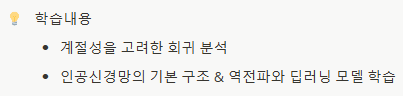

##**계절성을 고려한 회귀 분석 (Seasonal Regression Analysis)**

회귀 분석은 종속 변수와 독립 변수 간의 관계를 분석하는 통계 기법  
그러나 많은 데이터는 **시간에 따라 반복되는 계절적 패턴**을 가지고 있음   계절성을 고려하지 않으면 모델이 데이터의 패턴을 제대로 학습하지 못할 수 있음

계절성을 고려한 회귀 분석은 **시간 요소(예: 월, 분기, 연도 등)를 독립 변수로 추가하여 계절적 변동을 반영하는 방법**  

1. **더미 변수(Dummy Variables) 추가**
    - 월별, 계절별 변화를 반영하기 위해 더미 변수 생성  
    예를 들어, 12개월 데이터를 분석할 경우, 11개의 더미 변수를 생성하여 특정 월이 영향을 주는지를 확인할 수 있음
2. **푸리에 변환(Fourier Transformation)**
    - 계절적 패턴을 사인(Sine) 및 코사인(Cosine) 함수를 이용해 모델링  
    이는 특정 주기성을 더 정확하게 반영할 수 있는 방법
3. **이동 평균(Moving Average) 또는 지수 평활법(Exponential Smoothing)**
    - 계절성을 제거하거나 보정하는 방식으로 사용
4. **ARIMA 또는 SARIMA 모델 사용**
    - 시계열 데이터를 다룰 때 자주 사용되는 모델이며, 계절 조정이 포함된 `SARIMA` 모델은 계절성을 반영할 수 있음

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     35.74
Date:                Mon, 17 Mar 2025   Prob (F-statistic):           3.16e-08
Time:                        00:21:07   Log-Likelihood:                -54.719
No. Observations:                  24   AIC:                             117.4
Df Residuals:                      20   BIC:                             122.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.4226      1.166     44.944      0.0

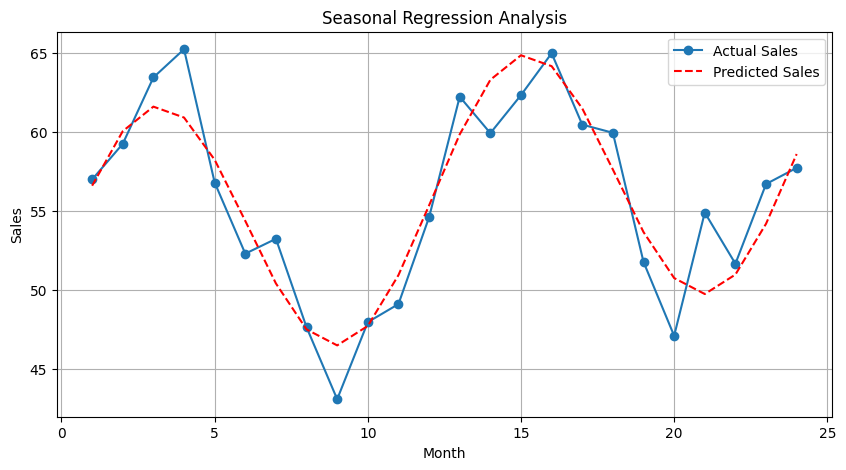

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 데이터 생성 (12개월 주기의 계절성을 가진 시계열 데이터)
np.random.seed(42)
months = np.arange(1, 25)  # 2년 (24개월) 데이터
seasonal_effect = 10 * np.sin(2 * np.pi * months / 12)  # 계절성 반영 (사인 함수)
trend = 0.5 * months  # 증가하는 추세
noise = np.random.normal(0, 3, size=len(months))  # 랜덤 노이즈 추가
y = 50 + trend + seasonal_effect + noise  # 최종 데이터

# 데이터프레임 생성
df = pd.DataFrame({"Month": months, "Sales": y})
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)  # 계절성을 위한 사인 변환
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)  # 계절성을 위한 코사인 변환

# 독립 변수 설정 (추세 + 계절성 반영)
X = df[["Month", "Month_sin", "Month_cos"]]
X = sm.add_constant(X)  # 상수 추가 (절편)

# 회귀 분석 수행
model = sm.OLS(df["Sales"], X).fit()

# 결과 출력
print(model.summary())

# 예측 값 계산
df["Predicted"] = model.predict(X)

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["Sales"], label="Actual Sales", marker='o')
plt.plot(df["Month"], df["Predicted"], label="Predicted Sales", linestyle="dashed", color="red")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Seasonal Regression Analysis")
plt.legend()
plt.grid()
plt.show()



---

### **1. 시나리오**

한 온라인 쇼핑몰에서 마케팅 전략의 효과를 분석하려고 합니다.

- 주요 관심 대상: **월별 광고비, 프로모션 여부, 트래픽(방문자 수)** 가 **매출**에 미치는 영향
- 계절성을 고려: 특정 계절(예: 연말, 여름 시즌)에 따른 매출 변동 반영
- 분석 목표: **광고비와 프로모션이 매출에 미치는 영향 분석 및 향후 매출 예측**


### **2. 데이터 생성 (계절성 반영)**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 데이터 생성 설정
np.random.seed(42)
months = np.arange(1, 25)  # 2년(24개월) 데이터
seasonal_effect = 20 * np.sin(2 * np.pi * months / 12)  # 계절성 반영 (사인 함수)
trend = 2 * months  # 증가하는 추세
noise = np.random.normal(0, 5, size=len(months))  # 랜덤 노이즈 추가

# 광고비, 트래픽, 프로모션 여부 설정
ad_spend = np.random.randint(50, 150, size=len(months))  # 광고비 (랜덤)
traffic = np.random.randint(1000, 5000, size=len(months))  # 방문자 수 (랜덤)
promotion = np.random.choice([0, 1], size=len(months), p=[0.7, 0.3])  # 프로모션 여부 (30% 확률)

# 최종 매출 데이터 생성 (광고비, 트래픽, 프로모션이 영향을 미침)
sales = 200 + (0.8 * ad_spend) + (0.05 * traffic) + (50 * promotion) + trend + seasonal_effect + noise

# 데이터프레임 생성
df = pd.DataFrame({
    "Month": months,
    "Ad_Spend": ad_spend,
    "Traffic": traffic,
    "Promotion": promotion,
    "Sales": sales
})

# 계절성 반영을 위한 사인 및 코사인 추가
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# 데이터 확인 (상위 5개 행 출력)
print(df.head())

   Month  Ad_Spend  Traffic  Promotion       Sales  Month_sin     Month_cos
0      1       113     3253          1  517.533571   0.500000  8.660254e-01
1      2        52     4152          0  469.829187   0.866025  5.000000e-01
2      3       100     2955          0  456.988443   1.000000  6.123234e-17
3      4        56     2585          0  406.985657   0.866025 -5.000000e-01
4      5        70     4943          0  521.979233   0.500000 -8.660254e-01


###**3. 회귀 분석 및 예측 코드 (sklearn)**

Mean Absolute Error (MAE): 8.61
R-squared (R²): 0.9520


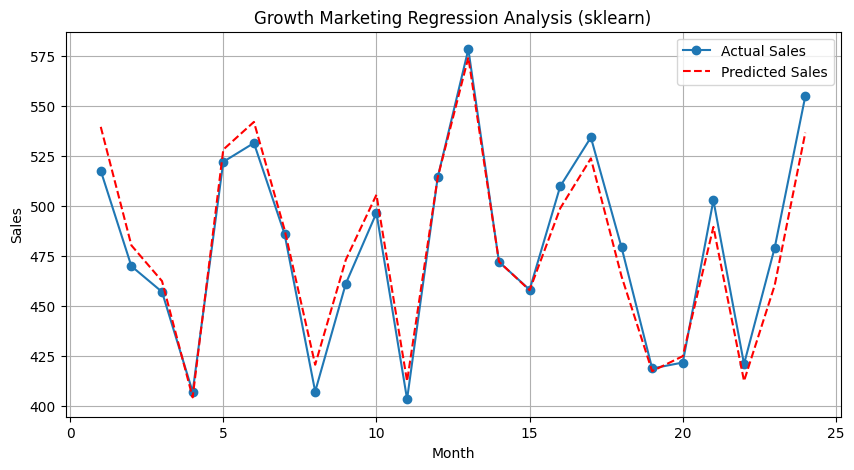

In [3]:
# 독립 변수 (계절성 반영)
X = df[["Ad_Spend", "Traffic", "Promotion", "Month_sin", "Month_cos"]]
y = df["Sales"]

# 모델 학습
model = LinearRegression()
model.fit(X, y)

# 예측 값 계산
df["Predicted_Sales"] = model.predict(X)

# 성능 평가
mae = mean_absolute_error(df["Sales"], df["Predicted_Sales"])
r2 = r2_score(df["Sales"], df["Predicted_Sales"])
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["Sales"], label="Actual Sales", marker='o')
plt.plot(df["Month"], df["Predicted_Sales"], label="Predicted Sales", linestyle="dashed", color="red")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Growth Marketing Regression Analysis (sklearn)")
plt.legend()
plt.grid()
plt.show()

### **결과 해석**

- `LinearRegression`을 사용하여 **광고비(Ad_Spend)**, **트래픽(Traffic)**, **프로모션(Promotion)** 이 매출에 미치는 영향을 분석했습니다.
- **계절성 반영**을 위해 `Month_sin` 및 `Month_cos` 변수를 추가하여 **특정 월의 매출 변동을 모델이 학습**하도록 했습니다.
- `Mean Absolute Error (MAE)` 및 `R²` 점수를 확인하여 **모델의 성능을 평가**했습니다.
- 그래프에서 **실제 매출과 예측 매출의 차이를 시각적으로 확인**할 수 있습니다.



---

### **1. 시나리오**

한 온라인 서비스 기업이 고객 유지율(리텐션)을 높이기 위해 다양한 그로스 마케팅 전략을 실행했습니다. 이 전략에는 **개인화된 추천 시스템 도입**, **이메일 캠페인**, **앱 내 알림** 등이 포함되었습니다. 이러한 전략이 **월별 활성 사용자 수(MAU)** 에 어떤 영향을 미쳤는지 분석하고자 합니다.


### **2. 데이터 생성**

In [4]:
import numpy as np
import pandas as pd

# 데이터 생성 설정
np.random.seed(42)
months = np.arange(1, 13)  # 12개월 데이터
base_users = 10000  # 기본 활성 사용자 수

# 마케팅 전략 효과 (가중치)
personalization_effect = 0.05  # 개인화 추천 시스템 도입 효과
email_campaign_effect = 0.03  # 이메일 캠페인 효과
in_app_notification_effect = 0.02  # 앱 내 알림 효과

# 각 전략의 실행 여부 (1: 실행, 0: 미실행)
personalization = np.array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])  # 3월부터 도입
email_campaign = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])  # 격월로 실행
in_app_notification = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])  # 5월부터 도입

# 월별 활성 사용자 수 계산
mau = base_users * (1 + personalization * personalization_effect +
                    email_campaign * email_campaign_effect +
                    in_app_notification * in_app_notification_effect)

# 노이즈 추가
noise = np.random.normal(0, 200, size=len(months))
mau = mau + noise

# 데이터프레임 생성
df = pd.DataFrame({
    "Month": months,
    "Personalization": personalization,
    "Email_Campaign": email_campaign,
    "In_App_Notification": in_app_notification,
    "MAU": mau
})

# 데이터 확인
print(df)

    Month  Personalization  Email_Campaign  In_App_Notification           MAU
0       1                0               0                    0  10099.342831
1       2                0               1                    0  10272.347140
2       3                1               0                    0  10629.537708
3       4                1               1                    0  11104.605971
4       5                1               0                    1  10653.169325
5       6                1               1                    1  10953.172609
6       7                1               0                    1  11015.842563
7       8                1               1                    1  11153.486946
8       9                1               0                    1  10606.105123
9      10                1               1                    1  11108.512009
10     11                1               0                    1  10607.316461
11     12                1               1                    1 

###**3. 회귀 분석 및 예측 코드**

               Feature  Coefficient
0      Personalization   681.226854
1       Email_Campaign   314.610785
2  In_App_Notification     8.485546
Mean Absolute Error (MAE): 107.48
R-squared (R²): 0.8557


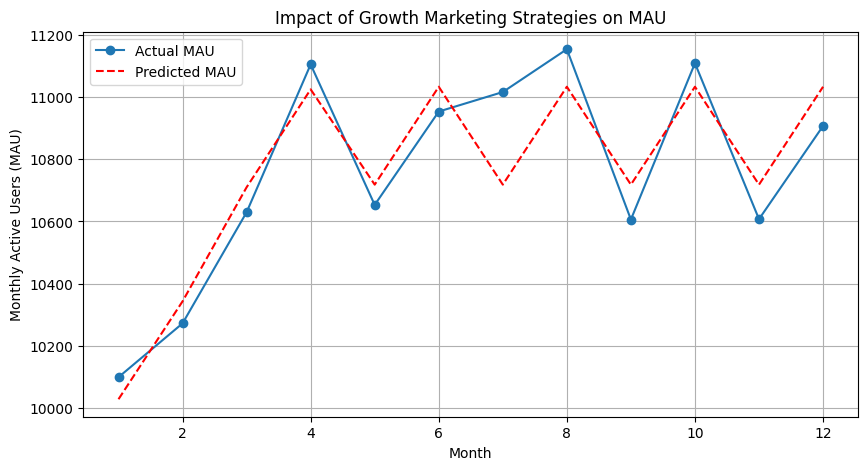

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 독립 변수 및 종속 변수 설정
X = df[["Personalization", "Email_Campaign", "In_App_Notification"]]
y = df["MAU"]

# 모델 학습
model = LinearRegression()
model.fit(X, y)

# 회귀 계수 출력
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)

# 예측 값 계산
df["Predicted_MAU"] = model.predict(X)

# 성능 평가
mae = mean_absolute_error(df["MAU"], df["Predicted_MAU"])
r2 = r2_score(df["MAU"], df["Predicted_MAU"])
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["MAU"], label="Actual MAU", marker='o')
plt.plot(df["Month"], df["Predicted_MAU"], label="Predicted MAU", linestyle="dashed", color="red")
plt.xlabel("Month")
plt.ylabel("Monthly Active Users (MAU)")
plt.title("Impact of Growth Marketing Strategies on MAU")
plt.legend()
plt.grid()
plt.show()

### **결과 해석**

- **회귀 계수**: 각 마케팅 전략의 회귀 계수는 해당 전략이 MAU에 미치는 영향을 나타냅니다. 예를 들어, 개인화 추천 시스템의 회귀 계수가 500이라면, 이를 도입했을 때 평균적으로 MAU가 500명 증가함을 의미합니다.
- **모델 성능**: `R²` 값은 모델이 실제 데이터를 얼마나 잘 설명하는지를 나타내며, 1에 가까울수록 설명력이 높습니다. `MAE`는 예측 값과 실제 값의 평균 절대 오차를 나타냅니다.
- **시각화**: 그래프를 통해 실제 MAU와 예측된 MAU의 변화를 비교하여 모델의 예측 정확도를 시각적으로 확인할 수 있습니다.



---

### **깜짝 조사!**

웹을 검색해서 사회, 정치, 경제, 문화적 사건을 중심으로 “화장품 유통”에 영향을 주는 주기 요소를 찾아 정리 해 보세요(주기, 이벤트) - 아래의 코드는 퓨리에변환식을 사용해 주기를 반영한 코드임.

In [8]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 57.7 MB/s eta 0:00:00


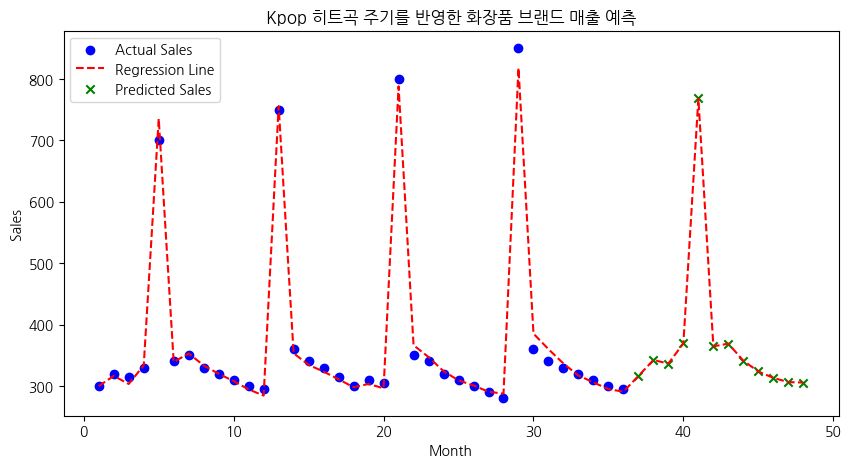

Mean Absolute Error (MAE): 7.67
R² Score: 0.99


,Month,Ad_Spend,SNS_Viral_Score,Traffic,Promotion,Hit_Song_Sin,Hit_Song_Cos,Predicted_Sales
0,37,80,1.5,1200,0,-1.490423e-01,-0.988831,316.207440
1,38,100,2.0,1300,0,-6.801727e-01,-0.733052,342.193270
2,39,90,1.8,1250,0,-9.749279e-01,-0.222521,336.442583
3,40,110,2.2,1350,1,-9.308737e-01,0.365341,369.305995
4,41,220,8.0,4200,1,-5.633201e-01,0.826239,768.205473
5,42,120,3.0,1400,0,-9.797174e-16,1.000000,364.513765
6,43,130,3.5,1450,0,5.633201e-01,0.826239,368.831119
7,44,110,2.5,1300,0,9.308737e-01,0.365341,341.131144
8,45,100,2.0,1200,0,9.749279e-01,-0.222521,323.540918
9,46,90,1.8,1150,0,6.801727e-01,-0.733052,313.126755


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 데이터 딕셔너리 정의 (Kpop 히트곡 주기성만 반영)
months = np.arange(1, 37)  # 1~36개월 데이터

data = {
    "Month": months,
    "Sales": [
        300, 320, 315, 330, 700, 340, 350, 330, 320, 310, 300, 295,
        750, 360, 340, 330, 315, 300, 310, 305, 800, 350, 340, 320,
        310, 300, 290, 280, 850, 360, 340, 330, 320, 310, 300, 295
    ],
    "Ad_Spend": [
        80, 100, 90, 110, 220, 120, 130, 110, 100, 90, 80, 75,
        240, 140, 120, 110, 95, 80, 90, 85, 260, 130, 120, 100,
        90, 80, 70, 60, 280, 140, 130, 110, 100, 90, 80, 75
    ],
    "SNS_Viral_Score": [
        1.5, 2, 1.8, 2.2, 8, 3, 3.5, 2.5, 2, 1.8, 1.5, 1,
        9, 4, 3.5, 3, 2.5, 2, 1.5, 1.2, 10, 5, 4.5, 4,
        3.5, 2.5, 2, 1.5, 12, 4, 3.8, 3.2, 2.7, 2.1, 1.8, 1.3
    ],
    "Traffic": [
        1200, 1300, 1250, 1350, 4200, 1400, 1450, 1300, 1200, 1150, 1100, 1050,
        4300, 1500, 1400, 1300, 1200, 1100, 1050, 1000, 4400, 1600, 1500, 1400,
        1300, 1200, 1100, 1050, 4600, 1550, 1400, 1300, 1200, 1150, 1100, 1050
    ],
    "Promotion": [
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0
    ]
}

# 2. Kpop 히트곡 주기를 반영한 주기 변수 추가 (9~12개월 주기, 평균 10.5개월)
data["Hit_Song_Sin"] = np.sin(2 * np.pi * data["Month"] / 10.5)
data["Hit_Song_Cos"] = np.cos(2 * np.pi * data["Month"] / 10.5)

# 3. 딕셔너리를 DataFrame으로 변환
df = pd.DataFrame(data)

# 4. 선형 회귀 분석을 위한 데이터 준비
X = df[["Month", "Ad_Spend", "SNS_Viral_Score", "Traffic", "Promotion", "Hit_Song_Sin", "Hit_Song_Cos"]]
y = df["Sales"]

# 5. 선형 회귀 모델 학습
model = LinearRegression()
model.fit(X, y)

# 6. 향후 12개월 예측 (37~48개월)
future_months = np.arange(37, 49)
future_data = {
    "Month": future_months,
    "Ad_Spend": [80, 100, 90, 110, 220, 120, 130, 110, 100, 90, 80, 75],
    "SNS_Viral_Score": [1.5, 2, 1.8, 2.2, 8, 3, 3.5, 2.5, 2, 1.8, 1.5, 1],
    "Traffic": [1200, 1300, 1250, 1350, 4200, 1400, 1450, 1300, 1200, 1150, 1100, 1050],
    "Promotion": [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
}

# 7. Kpop 히트곡 주기 반영 (향후 12개월)
future_data["Hit_Song_Sin"] = np.sin(2 * np.pi * future_data["Month"] / 10.5)
future_data["Hit_Song_Cos"] = np.cos(2 * np.pi * future_data["Month"] / 10.5)

# 8. DataFrame 변환 후 매출 예측
future_df = pd.DataFrame(future_data)
predicted_sales = model.predict(future_df)

# 9. 결과 시각화 (점선 연결)
plt.figure(figsize=(10, 5))

# 실제 데이터 점 (파란색)
plt.scatter(df["Month"], df["Sales"], color="blue", label="Actual Sales")

# 기존 데이터 + 예측 데이터를 하나의 배열로 연결
combined_months = np.concatenate((df["Month"], future_df["Month"]))
combined_sales = np.concatenate((model.predict(X), predicted_sales))

# 점선 스타일로 회귀선 표시
plt.plot(combined_months, combined_sales, color="red", linestyle="dashed", label="Regression Line")

# 예측값 (녹색 X)
plt.scatter(future_df["Month"], predicted_sales, color="green", marker="x", label="Predicted Sales")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Kpop 히트곡 주기를 반영한 화장품 브랜드 매출 예측")
plt.legend()
plt.show()

# 10. 성능 평가
y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# 11. 향후 12개월 예측값 출력
future_df["Predicted_Sales"] = predicted_sales
display(future_df)



---

### **1. 시나리오**

쿠팡은 경쟁이 치열한 한국 e커머스 시장에서 **신규 고객 유입**을 극대화하기 위해 다양한 마케팅 전략을 실행하였습니다. 주요 전략은 다음과 같습니다.

1. **할인 프로모션**: 특정 상품군에 대해 5%에서 22%까지의 할인율을 적용하여 가격 경쟁력을 확보하였습니다.
2. **무료 배송 서비스**: 일정 금액 이상 구매 시 무료 배송을 제공하거나, 월 구독형 서비스인 '로켓와우' 멤버십을 통해 무료 배송 혜택을 제공하였습니다.
3. **SNS 광고 캠페인**: Facebook, Instagram, YouTube 등 다양한 SNS 플랫폼에서 적극적인 광고 캠페인을 전개하여 브랜드 인지도와 고객 유입을 증대시켰습니다.

**목표**: 이러한 마케팅 전략이 **신규 고객 유입**에 미치는 영향을 분석하고, 각 전략의 효과성을 정량적으로 평가하여 향후 마케팅 전략 수립에 활용하고자 합니다.

**2. 데이터 생성 (하드코딩된 실제 사례 기반 데이터)**

쿠팡의 2024년 월별 마케팅 활동과 신규 고객 유입 데이터를 가정하여 다음과 같이 구성하였습니다.

In [11]:
import pandas as pd

# 하드코딩된 데이터 (2024년 1월 ~ 12월)
data = {
    "Month": list(range(1, 13)),
    "Discount_Rate": [5, 10, 7, 15, 12, 8, 20, 18, 22, 10, 12, 15],  # 할인율(%)
    "Free_Shipping": [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1],  # 무료 배송 여부 (1: 제공, 0: 미제공)
    "SNS_Ad_Spend": [200, 300, 250, 400, 350, 280, 500, 480, 550, 300, 350, 450],  # SNS 광고비(단위: 만 원)
    "New_Customers": [5300, 6700, 5800, 7800, 7200, 5900, 9200, 9100, 9800, 6500, 7000, 8300]  # 신규 고객 수
}

# 데이터프레임 생성
df = pd.DataFrame(data)

# 데이터 확인
display(df)

,Month,Discount_Rate,Free_Shipping,SNS_Ad_Spend,New_Customers
0,1,5,0,200,5300
1,2,10,1,300,6700
2,3,7,0,250,5800
3,4,15,1,400,7800
4,5,12,0,350,7200
5,6,8,1,280,5900
6,7,20,1,500,9200
7,8,18,1,480,9100
8,9,22,1,550,9800
9,10,10,0,300,6500


**3. 회귀 분석 및 예측 코드**

이제 위의 데이터를 활용하여 각 마케팅 전략이 신규 고객 유입에 미치는 영향을 분석하고, 향후 전략 수립에 필요한 인사이트를 도출하겠습니다.

         Feature  Coefficient
0  Discount_Rate   111.142532
1  Free_Shipping   -96.305290
2   SNS_Ad_Spend     8.280208
Mean Absolute Error (MAE): 100.08
R-squared (R²): 0.9920


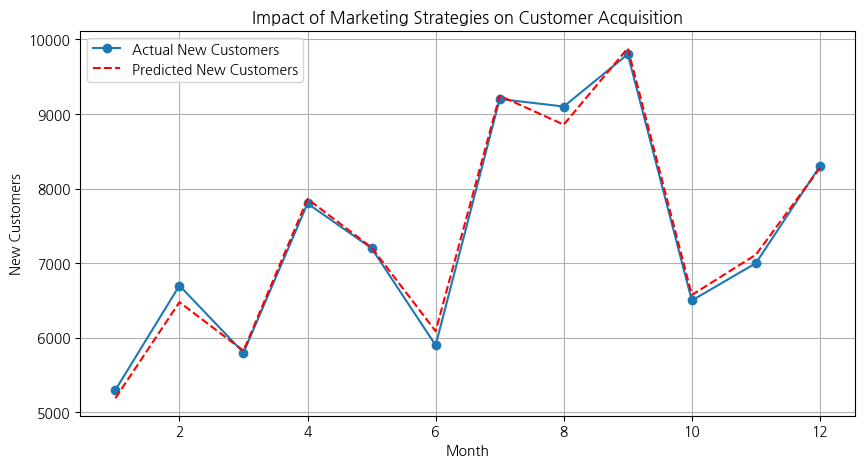

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 독립 변수 및 종속 변수 설정
X = df[["Discount_Rate", "Free_Shipping", "SNS_Ad_Spend"]]
y = df["New_Customers"]

# 모델 학습
model = LinearRegression()
model.fit(X, y)

# 회귀 계수 출력
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)

# 예측 값 계산
df["Predicted_New_Customers"] = model.predict(X)

# 성능 평가
mae = mean_absolute_error(df["New_Customers"], df["Predicted_New_Customers"])
r2 = r2_score(df["New_Customers"], df["Predicted_New_Customers"])
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

# 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["New_Customers"], label="Actual New Customers", marker='o')
plt.plot(df["Month"], df["Predicted_New_Customers"], label="Predicted New Customers", linestyle="dashed", color="red")
plt.xlabel("Month")
plt.ylabel("New Customers")
plt.title("Impact of Marketing Strategies on Customer Acquisition")
plt.legend()
plt.grid()
plt.show()

**4. 결과 해석**

1. **회귀 계수 분석**:
    - `Discount_Rate`: 할인율이 1% 증가할 때마다 신규 고객 수가 얼마나 증가하는지를 나타냅니다.
    - `Free_Shipping`: 무료 배송을 제공한 달에 신규 고객 수가 얼마나 증가하는지를 보여줍니다.
    - `SNS_Ad_Spend`: SNS 광고비를 1만 원 증가시켰을 때 신규 고객 수의 증가량을 나타냅니다.
2. **모델 성능 평가**:
    - `R²` 값: 모델이 전체 변동성 중 얼마나 설명하는지를 나타내며, 1에 가까울수록 모델의 설명력이 높습니다.
    - `MAE` 값: 평균 절대 오차로, 예측 값과 실제 값의 평균적인 차이를 나타냅니다. 값이 작을수록 예측 정확도가 높습니다.
3. **시각화 분석**:
    - 실제 신규 고객 수와 예측된 신규 고객 수를 비교하여 모델의 예측 정확도를 시각적으로 확인할 수 있습니다.



---

### **시나리오: 계절성을 고려한 매출 예측 모델**

한 회사는 3년간(2019~2021년)의 월별 매출 데이터를 분석하여 계절성을 반영한 매출 예측 모델을 개발하고자 한다.

특정 월의 매출 패턴은 다음과 같다.

- **여름(6~8월):** 매출 증가
- **겨울(12~2월):** 매출 감소
- **봄(3,5월) 및 가을(9,11월) :** 중간 수준

이를 기반으로 월별 계절성을 반영한 더미 변수를 생성하여 선형 회귀 모델을 학습하고, 향후 매출 예측에 활용할 수 있도록 한다.

R² Score: 0.8129

Regression Coefficients:
         Feature  Coefficient
0  Season_Spring        -20.0
1  Season_Summer         90.0
2  Season_Winter       -115.0


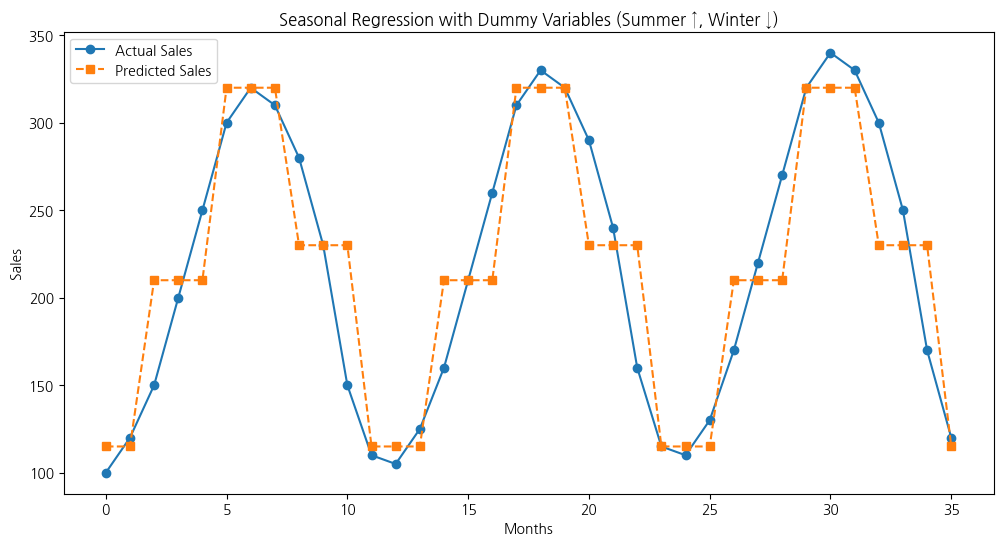


Data with Predictions:
 Year  Month  Sales  Season_Spring  Season_Summer  Season_Winter  Predicted_Sales
 2019      1    100          False          False           True            115.0
 2019      2    120          False          False           True            115.0
 2019      3    150           True          False          False            210.0
 2019      4    200           True          False          False            210.0
 2019      5    250           True          False          False            210.0
 2019      6    300          False           True          False            320.0
 2019      7    320          False           True          False            320.0
 2019      8    310          False           True          False            320.0
 2019      9    280          False          False          False            230.0
 2019     10    230          False          False          False            230.0
 2019     11    150          False          False          False          

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 3년간 월별 매출 데이터 (2019~2021)
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Sales': [
        100, 120, 150, 200, 250, 300, 320, 310, 280, 230, 150, 110,  # 2019년
        105, 125, 160, 210, 260, 310, 330, 320, 290, 240, 160, 115,  # 2020년
        110, 130, 170, 220, 270, 320, 340, 330, 300, 250, 170, 120   # 2021년
    ]
}

df = pd.DataFrame(data)

# 계절 변수 추가
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                             'Spring' if x in [3, 4, 5] else
                                             'Summer' if x in [6, 7, 8] else
                                             'Fall')

# 계절을 더미 변수로 변환 (기준값: Winter)
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

# 독립 변수 (X)와 종속 변수 (Y) 설정
X = df.drop(columns=['Sales', 'Year', 'Month'])  # 'Month'는 제거
Y = df['Sales']

# 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X, Y)

# 예측
Y_pred = model.predict(X)

# 모델 평가
r2 = r2_score(Y, Y_pred)
print(f"R² Score: {r2:.4f}")

# 회귀 계수 출력
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nRegression Coefficients:")
print(coefficients)

# 예측값 데이터프레임에 추가
df['Predicted_Sales'] = Y_pred

# 실제값과 예측값 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label="Actual Sales", marker="o")
plt.plot(df.index, df['Predicted_Sales'], label="Predicted Sales", linestyle="--", marker="s")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("Seasonal Regression with Dummy Variables (Summer ↑, Winter ↓)")
plt.legend()
plt.show()

# 전체 데이터 출력
print("\nData with Predictions:")
print(df.to_string(index=False))



---

### **문제 1: 계절별 온라인 쇼핑 매출 예측**

### **시나리오**

한 온라인 쇼핑몰에서는 연중 다양한 프로모션과 할인 행사를 진행하며, 계절별로 매출이 변화하는 패턴을 보인다.

특히, 여름과 연말에 매출이 급증하는 경향이 있다.

이제 월별 매출 데이터를 분석하고 **더미 변수를 활용하여 계절성을 반영한 선형 회귀 모델을 구축하여 매출을 예측**하고자 한다.

### **하드코딩된 데이터**

In [ ]:
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Sales': [
        150, 180, 220, 280, 320, 400, 450, 470, 380, 340, 500, 550,  # 2019년
        160, 190, 230, 290, 330, 410, 460, 480, 390, 350, 510, 560,  # 2020년
        170, 200, 240, 300, 340, 420, 470, 490, 400, 360, 520, 570   # 2021년
    ]
}

R² Score: 0.8753

Regression Coefficients:
            Feature  Coefficient
0     Season_Spring  -133.333333
1     Season_Summer    33.333333
2     Season_Winter  -241.666667
3  Season_Winter_연말   143.333333


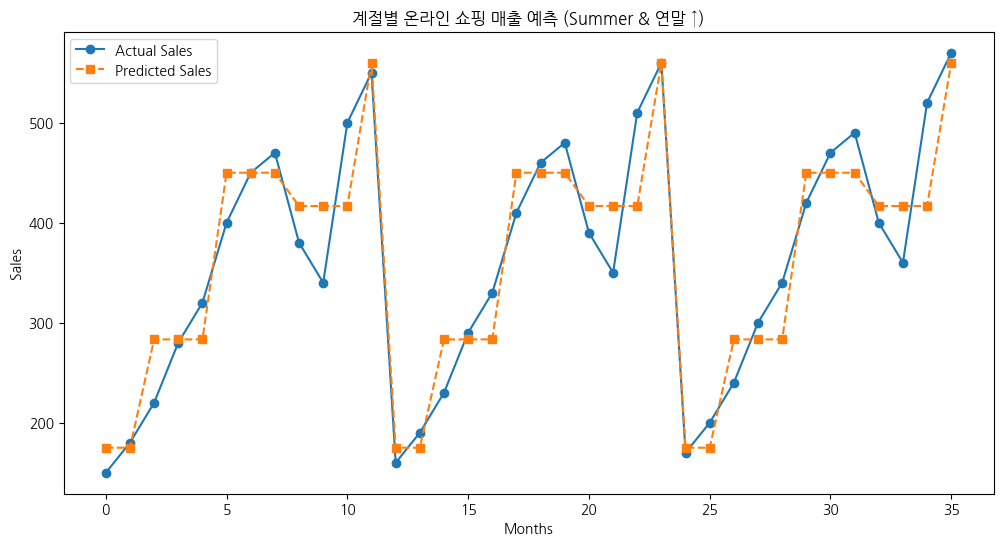


Data with Predictions:
 Year  Month  Sales  Season_Spring  Season_Summer  Season_Winter  Season_Winter_연말  Predicted_Sales
 2019      1    150          False          False           True             False       175.000000
 2019      2    180          False          False           True             False       175.000000
 2019      3    220           True          False          False             False       283.333333
 2019      4    280           True          False          False             False       283.333333
 2019      5    320           True          False          False             False       283.333333
 2019      6    400          False           True          False             False       450.000000
 2019      7    450          False           True          False             False       450.000000
 2019      8    470          False           True          False             False       450.000000
 2019      9    380          False          False          False            

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Sales': [
        150, 180, 220, 280, 320, 400, 450, 470, 380, 340, 500, 550,  # 2019년
        160, 190, 230, 290, 330, 410, 460, 480, 390, 350, 510, 560,  # 2020년
        170, 200, 240, 300, 340, 420, 470, 490, 400, 360, 520, 570   # 2021년
    ]
}

df = pd.DataFrame(data)

df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [1, 2] else
                                            'Winter_연말' if x in [12] else
                                            'Spring' if x in [3, 4, 5] else
                                            'Summer' if x in [6, 7, 8] else
                                            'Fall')

df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Sales', 'Year', 'Month'])
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nRegression Coefficients:")
print(coefficients)

df['Predicted_Sales'] = y_pred

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Sales'], label='Actual Sales', marker='o')
plt.plot(df.index, df['Predicted_Sales'], label='Predicted Sales', linestyle='--', marker='s')
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("계절별 온라인 쇼핑 매출 예측 (Summer & 연말 ↑)")
plt.legend()
plt.show()

print("\nData with Predictions:")
print(df.to_string(index=False))



---

### **문제 2: 지역별 대형마트 월별 방문자 수 예측**

### **시나리오**

한 대형마트 체인은 각 지역별로 월별 방문자 수를 기록하고 있다.

연말과 명절(1월, 9월, 12월)에는 방문자 수가 증가하는 패턴이 있으며, **월별 방문자 수를 예측하여 적절한 재고와 인력을 배치**하는 것이 목표다.

이를 위해 **더미 변수를 활용하여 월별 패턴을 반영한 선형 회귀 모델을 구축하고 방문자 수를 예측**한다.

### **하드코딩된 데이터**

In [ ]:
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Visitors': [
        1000, 1200, 1300, 1500, 1600, 1800, 2000, 1900, 1700, 1400, 2200, 2500,  # 2019년
        1050, 1250, 1350, 1550, 1650, 1850, 2050, 1950, 1750, 1450, 2250, 2550,  # 2020년
        1100, 1300, 1400, 1600, 1700, 1900, 2100, 2000, 1800, 1500, 2300, 2600   # 2021년
    ]
}

R² Score: 0.1645

Regression Coefficients:
         Feature  Coefficient
0  Season_Spring  -300.000000
1  Season_Summer   133.333333
2  Season_Winter  -200.000000


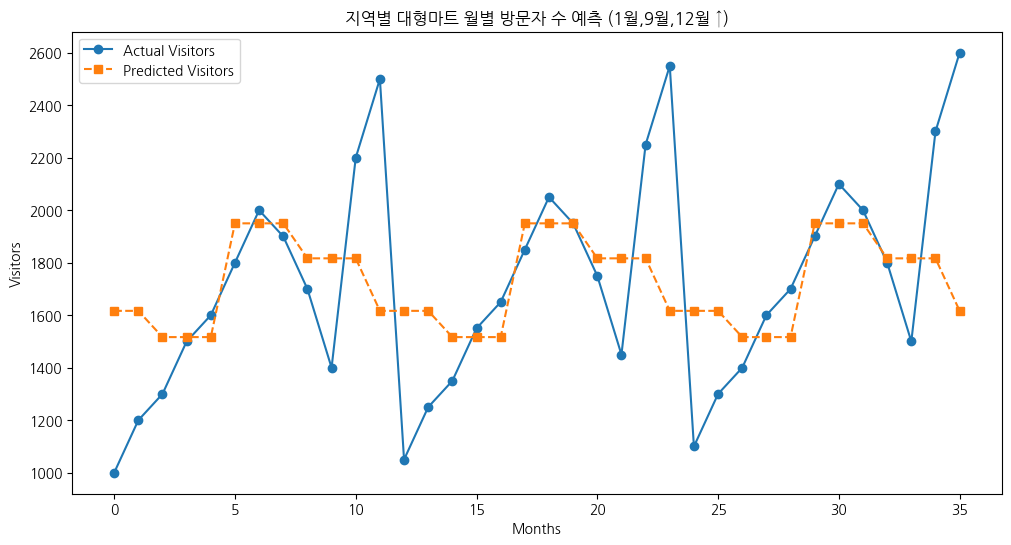


Data with Predictions:
 Year  Month  Visitors  Season_Spring  Season_Summer  Season_Winter  Predicted_Visitors
 2019      1      1000          False          False           True         1616.666667
 2019      2      1200          False          False           True         1616.666667
 2019      3      1300           True          False          False         1516.666667
 2019      4      1500           True          False          False         1516.666667
 2019      5      1600           True          False          False         1516.666667
 2019      6      1800          False           True          False         1950.000000
 2019      7      2000          False           True          False         1950.000000
 2019      8      1900          False           True          False         1950.000000
 2019      9      1700          False          False          False         1816.666667
 2019     10      1400          False          False          False         1816.666667
 2019   

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Visitors': [
        1000, 1200, 1300, 1500, 1600, 1800, 2000, 1900, 1700, 1400, 2200, 2500,  # 2019년
        1050, 1250, 1350, 1550, 1650, 1850, 2050, 1950, 1750, 1450, 2250, 2550,  # 2020년
        1100, 1300, 1400, 1600, 1700, 1900, 2100, 2000, 1800, 1500, 2300, 2600   # 2021년
    ]
}

df = pd.DataFrame(data)

df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                            'Spring' if x in [3, 4, 5] else
                                            'Summer' if x in [6, 7, 8] else
                                            'Fall')

df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Visitors', 'Year', 'Month'])
y = df['Visitors']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nRegression Coefficients:")
print(coefficients)

df['Predicted_Visitors'] = y_pred

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Visitors'], label='Actual Visitors', marker='o')
plt.plot(df.index, df['Predicted_Visitors'], label='Predicted Visitors', linestyle='--', marker='s')
plt.xlabel("Months")
plt.ylabel("Visitors")
plt.title("지역별 대형마트 월별 방문자 수 예측 (1월,9월,12월 ↑)")
plt.legend()
plt.show()

print("\nData with Predictions:")
print(df.to_string(index=False))



---

### **문제 3: 항공사 월별 탑승객 수 예측**

### **시나리오**

한 항공사는 월별 국내선 및 국제선의 탑승객 수를 기록하고 있다.

휴가철과 연말연시에는 항공 수요가 급증하는 경향이 있다.

이에 따라 **월별 탑승객 데이터를 활용하여 선형 회귀 모델을 구축하고, 향후 탑승객 수를 예측**하는 것이 목표다.

### **하드코딩된 데이터**

In [ ]:
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Passengers': [
        50000, 55000, 60000, 70000, 75000, 90000, 95000, 97000, 80000, 78000, 85000, 90000,  # 2019년
        52000, 57000, 62000, 72000, 77000, 92000, 97000, 99000, 82000, 79000, 87000, 92000,  # 2020년
        54000, 59000, 64000, 74000, 79000, 94000, 99000, 101000, 84000, 80000, 89000, 94000  # 2021년
    ]
}

R² Score: 0.5752

Regression Coefficients:
         Feature   Coefficient
0  Season_Spring -12333.333333
1  Season_Summer  13333.333333
2  Season_Winter -15666.666667


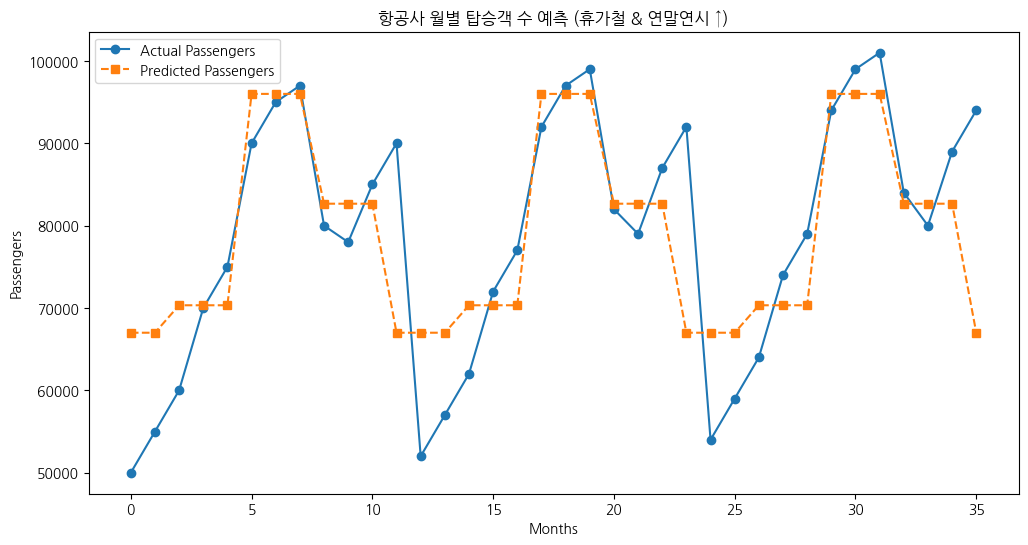


Data with Predictions:
 Year  Month  Passengers  Season_Spring  Season_Summer  Season_Winter  Predicted_Passengers
 2019      1       50000          False          False           True          67000.000000
 2019      2       55000          False          False           True          67000.000000
 2019      3       60000           True          False          False          70333.333333
 2019      4       70000           True          False          False          70333.333333
 2019      5       75000           True          False          False          70333.333333
 2019      6       90000          False           True          False          96000.000000
 2019      7       95000          False           True          False          96000.000000
 2019      8       97000          False           True          False          96000.000000
 2019      9       80000          False          False          False          82666.666667
 2019     10       78000          False          False  

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Passengers': [
        50000, 55000, 60000, 70000, 75000, 90000, 95000, 97000, 80000, 78000, 85000, 90000,  # 2019년
        52000, 57000, 62000, 72000, 77000, 92000, 97000, 99000, 82000, 79000, 87000, 92000,  # 2020년
        54000, 59000, 64000, 74000, 79000, 94000, 99000, 101000, 84000, 80000, 89000, 94000  # 2021년
    ]
}

df = pd.DataFrame(data)

df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                            'Spring' if x in [3, 4, 5] else
                                            'Summer' if x in [6, 7, 8] else
                                            'Fall')

df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Passengers', 'Year', 'Month'])
y = df['Passengers']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nRegression Coefficients:")
print(coefficients)

df['Predicted_Passengers'] = y_pred

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Passengers'], label='Actual Passengers', marker='o')
plt.plot(df.index, df['Predicted_Passengers'], label='Predicted Passengers', linestyle='--', marker='s')
plt.xlabel("Months")
plt.ylabel("Passengers")
plt.title("항공사 월별 탑승객 수 예측 (휴가철 & 연말연시 ↑)")
plt.legend()
plt.show()

print("\nData with Predictions:")
print(df.to_string(index=False))



---

### **문제 4: 백화점 월별 매출 예측**

### **시나리오**

한 백화점은 계절별로 판매량이 크게 변동한다.

특히, 여름과 연말**에는 매출이 급격히 증가**하는 패턴을 보인다.

백화점은 이 데이터를 활용하여 **월별 매출을 예측하고, 마케팅 전략을 수립**하고자 한다.

### **하드코딩된 데이터**

In [ ]:
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Sales': [
        5000, 5200, 5400, 5800, 6200, 7500, 8000, 8200, 7200, 6800, 9000, 9500,  # 2019년
        5100, 5300, 5500, 5900, 6300, 7600, 8100, 8300, 7300, 6900, 9100, 9600,  # 2020년
        5200, 5400, 5600, 6000, 6400, 7700, 8200, 8400, 7400, 7000, 9200, 9700   # 2021년
    ]
}

R² Score: 0.3461

Regression Coefficients:
         Feature  Coefficient
0  Season_Spring -1866.666667
1  Season_Summer   233.333333
2  Season_Winter -1100.000000


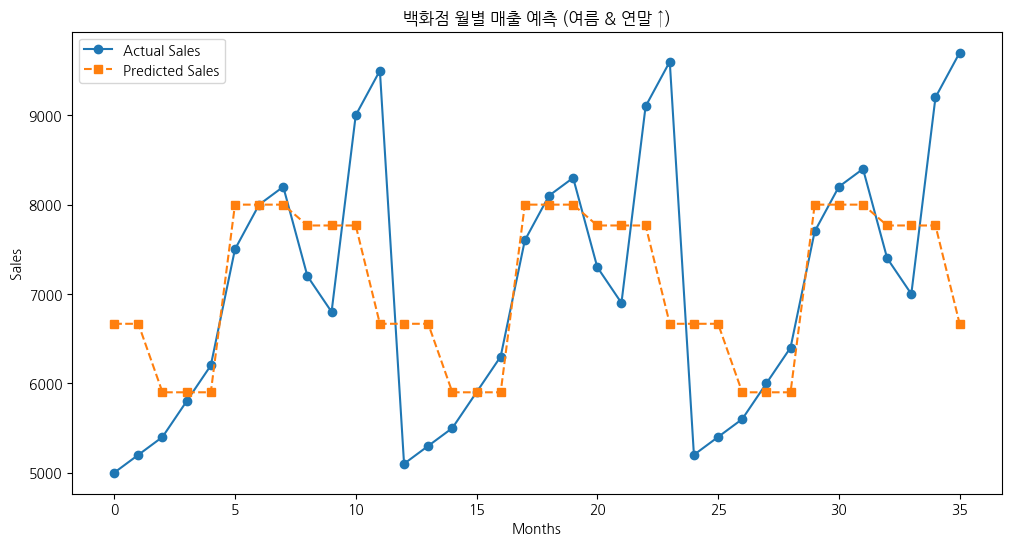


Data with Predictions:
 Year  Month  Sales  Season_Spring  Season_Summer  Season_Winter  Predicted_Sales
 2019      1   5000          False          False           True      6666.666667
 2019      2   5200          False          False           True      6666.666667
 2019      3   5400           True          False          False      5900.000000
 2019      4   5800           True          False          False      5900.000000
 2019      5   6200           True          False          False      5900.000000
 2019      6   7500          False           True          False      8000.000000
 2019      7   8000          False           True          False      8000.000000
 2019      8   8200          False           True          False      8000.000000
 2019      9   7200          False          False          False      7766.666667
 2019     10   6800          False          False          False      7766.666667
 2019     11   9000          False          False          False      7766

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Sales': [
        5000, 5200, 5400, 5800, 6200, 7500, 8000, 8200, 7200, 6800, 9000, 9500,  # 2019년
        5100, 5300, 5500, 5900, 6300, 7600, 8100, 8300, 7300, 6900, 9100, 9600,  # 2020년
        5200, 5400, 5600, 6000, 6400, 7700, 8200, 8400, 7400, 7000, 9200, 9700   # 2021년
    ]
}

df = pd.DataFrame(data)

df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                            'Spring' if x in [3, 4, 5] else
                                            'Summer' if x in [6, 7, 8] else
                                            'Fall')

df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Sales', 'Year', 'Month'])
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nRegression Coefficients:")
print(coefficients)

df['Predicted_Sales'] = y_pred

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Sales'], label='Actual Sales', marker='o')
plt.plot(df.index, df['Predicted_Sales'], label='Predicted Sales', linestyle='--', marker='s')
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("백화점 월별 매출 예측 (여름 & 연말 ↑)")
plt.legend()
plt.show()

print("\nData with Predictions:")
print(df.to_string(index=False))

### **문제 5: 호텔 월별 예약 수 예측**

### **시나리오**

한 호텔은 월별 예약 수를 분석하여 계절별 패턴을 찾고 있다.

특히, **여름 휴가철(6~8월)과 연말(12월)에 예약 수가 증가**하는 패턴을 보인다.

호텔은 이 데이터를 활용하여 **더미 변수를 포함한 선형 회귀 모델을 구축하여 다음 달의 예약 수를 예측**하고자 한다.

### **하드코딩된 데이터**

In [ ]:
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Bookings': [
        200, 220, 250, 300, 350, 500, 550, 570, 450, 400, 600, 650,  # 2019년
        210, 230, 260, 310, 360, 510, 560, 580, 460, 410, 610, 660,  # 2020년
        220, 240, 270, 320, 370, 520, 570, 590, 470, 420, 620, 670   # 2021년
    ]
}

R² Score: 0.8878

Regression Coefficients:
            Feature  Coefficient
0     Season_Spring  -183.333333
1     Season_Summer    56.666667
2     Season_Winter  -273.333333
3  Season_Winter_연말   166.666667


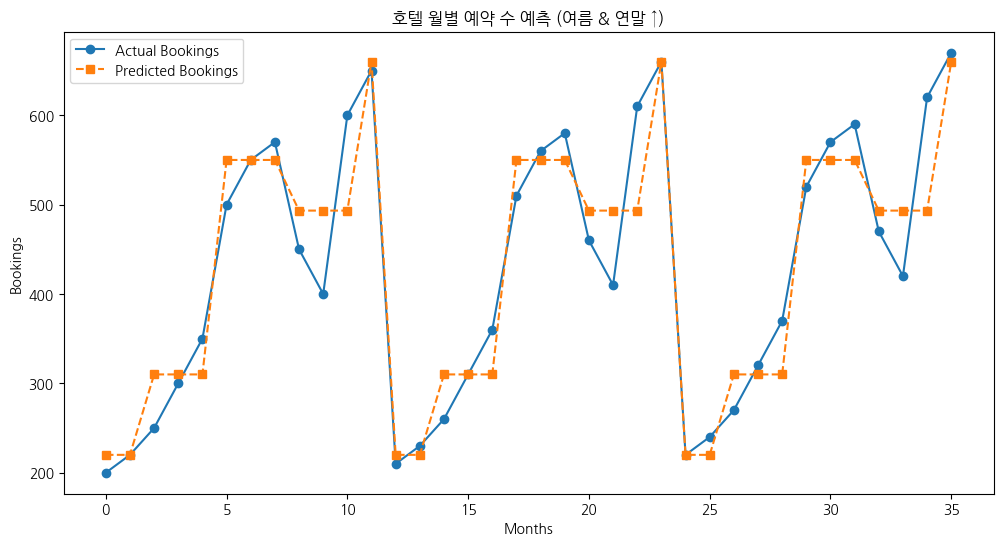


Data with Predictions:
 Year  Month  Bookings  Season_Spring  Season_Summer  Season_Winter  Season_Winter_연말  Predicted_Bookings
 2019      1       200          False          False           True             False          220.000000
 2019      2       220          False          False           True             False          220.000000
 2019      3       250           True          False          False             False          310.000000
 2019      4       300           True          False          False             False          310.000000
 2019      5       350           True          False          False             False          310.000000
 2019      6       500          False           True          False             False          550.000000
 2019      7       550          False           True          False             False          550.000000
 2019      8       570          False           True          False             False          550.000000
 2019      9       450

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Bookings': [
        200, 220, 250, 300, 350, 500, 550, 570, 450, 400, 600, 650,  # 2019년
        210, 230, 260, 310, 360, 510, 560, 580, 460, 410, 610, 660,  # 2020년
        220, 240, 270, 320, 370, 520, 570, 590, 470, 420, 620, 670   # 2021년
    ]
}

df = pd.DataFrame(data)

df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [1, 2] else
                                            'Winter_연말' if x == 12 else
                                            'Spring' if x in [3, 4, 5] else
                                            'Summer' if x in [6, 7, 8] else
                                            'Fall')

df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Bookings', 'Year', 'Month'])
y = df['Bookings']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nRegression Coefficients:")
print(coefficients)

df['Predicted_Bookings'] = y_pred

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Bookings'], label='Actual Bookings', marker='o')
plt.plot(df.index, df['Predicted_Bookings'], label='Predicted Bookings', linestyle='--', marker='s')
plt.xlabel("Months")
plt.ylabel("Bookings")
plt.title("호텔 월별 예약 수 예측 (여름 & 연말 ↑)")
plt.legend()
plt.show()

print("\nData with Predictions:")
print(df.to_string(index=False))



---

## **1. 인공신경망의 기본 구조 & 역전파와 딥러닝 모델 학습 설명**

### **1.1 인공신경망(Artificial Neural Network, ANN)의 기본 구조**

인공신경망(ANN)은 인간의 신경망을 모방하여 만들어진 모델로, 입력층(Input Layer), 은닉층(Hidden Layer), 출력층(Output Layer)으로 구성

- **입력층(Input Layer):** 입력 데이터를 받아들이는 층
- **은닉층(Hidden Layer):** 여러 개의 뉴런(Neuron)으로 구성되어 입력을 변환하는 층
- **출력층(Output Layer):** 최종 예측 값을 출력하는 층

각 뉴런은 활성화 함수(Activation Function)를 통해 비선형성을 추가하여 학습 능력 강화

### **1.2 역전파(Backpropagation) & 딥러닝 학습**

- 역전파(Backpropagation)는 신경망의 가중치를 업데이트하는 알고리즘으로, **오차를 최소화하기 위해 가중치를 조정하는 과정**

### **역전파 과정**

1. **순전파(Forward Propagation)**
    - 입력 데이터를 각 층을 거쳐 출력층까지 전달
    - 출력값을 계산하여 손실 함수(Loss Function)를 통해 오차 계산
2. **손실 계산(Loss Calculation)**
    - 예측값과 실제값의 차이를 계산하여 오차를 측정
    - 예: 평균제곱오차(Mean Squared Error, MSE)
3. **역전파(Backward Propagation)**
    - 손실을 기반으로 각 가중치에 대한 기울기(Gradient)를 계산
    - 체인룰(Chain Rule)을 사용하여 미분을 수행하여 기울기(Gradient) 계산
4. **가중치 업데이트(Weight Update)**
    - 경사 하강법(Gradient Descent)을 사용하여 가중치를 업데이트
    - 가중치  업데이트:
    
    (𝜶  : 학습률)

      𝑊 := 𝑊 - 𝜶 * ∂L/∂𝑊
        


## **2. 인공신경망 학습의 수식**

### **2.1 순전파(Forward Propagation)**

1. **가중치와 편향을 포함한 선형 변환**
    
    $$
    z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}
    $$
    
    - $W^{(l)}$:  $l$ 번째 층의 가중치
    - $b^{(l)}:$  $l$번째 층의 편향     
    - $a^{(l-1)}$: 이전 층의 활성화 값
2. **활성화 함수 적용**
    
    $$
    a^{(l)} = f(z^{(l)})
    $$
    
    - $f$는 활성화 함수 (예: ReLU, Sigmoid)

### **2.2 손실 함수(Loss Function)**

손실 함수 $L$는 실제값 $y$와 예측값 $\hat{y}$의 차이를 측정한다.

$$
L = \frac{1}{n} \sum (y - \hat{y})^2
$$

(MSE: 평균제곱오차)

### **2.3 역전파(Backpropagation)**

$$
\frac{\partial L}{\partial W^{(l)}} = \delta^{(l)} a^{(l-1)T}
$$

$$
\frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}
$$

$$
\delta^{(l)} = (W^{(l+1)T} \delta^{(l+1)}) \cdot f'(z^{(l)})
$$

( $\delta$는 오차 기울기)

### **2.4 가중치 업데이트(Gradient Descent)**

$$
W^{(l)} := W^{(l)} - \alpha \frac{\partial L}{\partial W^{(l)}}
$$

$$
b^{(l)} := b^{(l)} - \alpha \frac{\partial L}{\partial b^{(l)}}
$$



###**3. 인공신경망 학습**

In [32]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 생성 (XOR 문제를 확장한 예제)
np.random.seed(42)
X = np.random.rand(1000, 2) * 2 - 1  # [-1, 1] 범위의 랜덤 데이터
y = (X[:, 0] * X[:, 1] > 0).astype(int)  # XOR 패턴

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 인공신경망 모델 정의
model = Sequential([
    Dense(8, activation='relu', input_shape=(2,)),  # 은닉층 1
    Dense(8, activation='relu'),  # 은닉층 2
    Dense(1, activation='sigmoid')  # 출력층 (이진 분류)
])

# 모델 컴파일 (손실 함수 & 최적화 알고리즘 정의)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# 모델 평가
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# 예측값 확인
predictions = (model.predict(X_test) > 0.5).astype(int)
print("\nPredictions:")
print(predictions[:10])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5088 - loss: 0.7942 - val_accuracy: 0.4900 - val_loss: 0.7528
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5155 - loss: 0.6863 - val_accuracy: 0.5450 - val_loss: 0.6596
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5810 - loss: 0.6194 - val_accuracy: 0.5650 - val_loss: 0.6045
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6576 - loss: 0.5461 - val_accuracy: 0.6500 - val_loss: 0.5603
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7443 - loss: 0.5137 - val_accuracy: 0.8250 - val_loss: 0.5183
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8273 - loss: 0.4871 - val_accuracy: 0.8300 - val_loss: 0.4799
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8664 - loss: 0.4449 - val_accuracy: 0.8500 - val_loss: 0.4435
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8858 - loss: 0.4089 - val_accuracy: 0.8600

1. **모델 구조**
    - 입력층: 2개의 입력 뉴런
    - 은닉층: 8개 뉴런 × 2개층 (ReLU 활성화 함수 사용)
    - 출력층: 1개 뉴런 (Sigmoid 활성화 함수 사용)
2. **손실 함수 & 최적화 기법**
    - 이진 분류 문제이므로 `binary_crossentropy` 사용
    - Adam 최적화(`adam`): 가중치 업데이트 자동 조정
3. **모델 학습 과정**
    - 100 Epoch 동안 학습 수행
    - 학습 데이터(`train`)와 검증 데이터(`test`) 성능 비교
4. **예측 결과**
    - 학습된 모델로 테스트 데이터에 대한 예측 수행

---
역전파 학습이 진행되는 과정을 그래프로 표현하는 예시

- 손실 함수 값(예: `binary_crossentropy`)이 학습 과정에서 어떻게 감소하는지 시각화
- `matplotlib`을 사용하여 학습 과정에서의 **손실 값(loss) 및 정확도(accuracy)** 변화를 그래프로 그림

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.2973 - loss: 0.7499 - val_accuracy: 0.4550 - val_loss: 0.6971
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4399 - loss: 0.6956 - val_accuracy: 0.5200 - val_loss: 0.6728
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5647 - loss: 0.6687 - val_accuracy: 0.6650 - val_loss: 0.6431
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7487 - loss: 0.6376 - val_accuracy: 0.8700 - val_loss: 0.6114
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8469 - loss: 0.6093 - val_accuracy: 0.8950 - val_loss: 0.5799
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8805 - loss: 0.5775 - val_accuracy: 0.9000 - val_loss: 0.5422
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8595 - loss: 0.5484 - val_accuracy: 0.8800 - val_loss: 0.5021
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8741 - loss: 0.5061 - val_accuracy: 0.9000 - val_loss: 0.

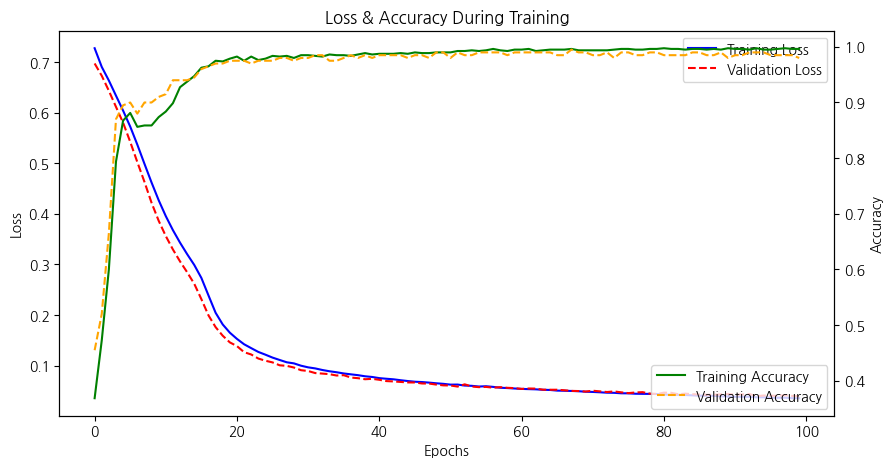

In [33]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 생성 (XOR 패턴 확장)
np.random.seed(42)
X = np.random.rand(1000, 2) * 2 - 1  # [-1, 1] 범위의 랜덤 데이터
y = (X[:, 0] * X[:, 1] > 0).astype(int)  # XOR 패턴

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 인공신경망 모델 정의
model = Sequential([
    Dense(8, activation='relu', input_shape=(2,)),  # 은닉층 1
    Dense(8, activation='relu'),  # 은닉층 2
    Dense(1, activation='sigmoid')  # 출력층 (이진 분류)
])

# 모델 컴파일 (손실 함수 & 최적화 알고리즘 정의)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습 (손실 및 정확도 기록)
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# 학습 과정 시각화
fig, ax1 = plt.subplots(figsize=(10, 5))

# 손실(loss) 그래프
ax1.plot(history.history['loss'], label='Training Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle="--")
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss & Accuracy During Training')
ax1.legend(loc='upper right')

# 정확도(accuracy) 그래프 (y축 공유)
ax2 = ax1.twinx()
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='green')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle="--")
ax2.set_ylabel('Accuracy')
ax2.legend(loc='lower right')

plt.show()

1. **데이터 생성**
    - 랜덤으로 데이터를 생성하고 XOR 패턴을 따른 `y` 값을 설정.
    - `StandardScaler`를 사용하여 데이터 정규화.
2. **신경망 모델 구성**
    - 은닉층 2개 (`ReLU` 활성화 함수 사용)
    - 출력층 1개 (`Sigmoid` 활성화 함수 사용)
    - `adam` 옵티마이저와 `binary_crossentropy` 손실 함수 사용
3. **학습 및 손실 기록**
    - `model.fit()`을 수행하여 `loss`와 `accuracy` 값을 저장
4. **그래프 시각화**
    - 파란색(`blue`) 선: 훈련 데이터 손실(Training Loss)
    - 빨간색(`red`) 점선: 검증 데이터 손실(Validation Loss)
    - 초록색(`green`) 선: 훈련 정확도(Training Accuracy)
    - 주황색(`orange`) 점선: 검증 정확도(Validation Accuracy)
    - `twinx()`를 사용하여 손실과 정확도를 같은 그래프에 표시



---

### **1. 시나리오**

한 온라인 서비스 기업이 고객 유지율(리텐션)을 높이기 위해 다양한 그로스 마케팅 전략을 실행했습니다. 이 전략에는 **개인화된 추천 시스템 도입**, **이메일 캠페인**, **앱 내 알림** 등이 포함되었습니다. 이러한 전략이 **월별 활성 사용자 수(MAU)** 에 어떤 영향을 미쳤는지 분석하고자 합니다.

- Deep learning 으로 구현
- Needed library install

In [1]:
!pip install --upgrade keras tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.3 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolve

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Mean Absolute Error (MAE): 1407.76
R-squared (R²): -18.8310


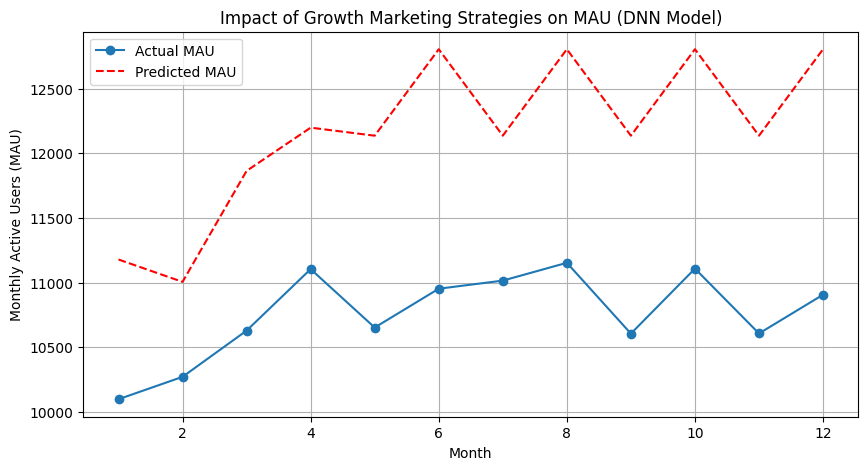

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(42)
months = np.arange(1, 13)  # 12개월 데이터
base_users = 10000

# 마케팅 전략 실행 여부
personalization = np.array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
email_campaign = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
in_app_notification = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

# 월별 MAU 계산
mau = base_users * (1 + personalization * 0.05 + email_campaign * 0.03 + in_app_notification * 0.02)
mau += np.random.normal(0, 200, size=len(months))  # 노이즈 추가

# 데이터프레임 생성
df = pd.DataFrame({
    "Month": months,
    "Personalization": personalization,
    "Email_Campaign": email_campaign,
    "In_App_Notification": in_app_notification,
    "MAU": mau
})

# 독립 변수 및 종속 변수 설정
X = df[["Personalization", "Email_Campaign", "In_App_Notification"]]
y = df["MAU"]

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 모델 생성 (input_shape을 Input() 레이어로 변경)
model = Sequential()
model.add(Input(shape=(X_scaled.shape[1],)))
model.add(Dense(64, activation=tf.keras.activations.relu))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation=tf.keras.activations.relu))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(16, activation=tf.keras.activations.relu))
model.add(Dense(1))  # 출력층 (MAU 예측)

# 모델 컴파일
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 모델 학습
history = model.fit(X_scaled, y, epochs=2000, batch_size=4, validation_split=0.2, verbose=0)

# 예측 값 계산
y_pred = model.predict(X_scaled).flatten()

# 성능 평가
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["MAU"], label="Actual MAU", marker='o')
plt.plot(df["Month"], y_pred, label="Predicted MAU", linestyle="dashed", color="red")
plt.xlabel("Month")
plt.ylabel("Monthly Active Users (MAU)")
plt.title("Impact of Growth Marketing Strategies on MAU (DNN Model)")
plt.legend()
plt.grid()
plt.show()

#### **epochs 2000 vs 10,000 비교**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Mean Absolute Error (MAE): 337.76
R-squared (R²): -0.5274


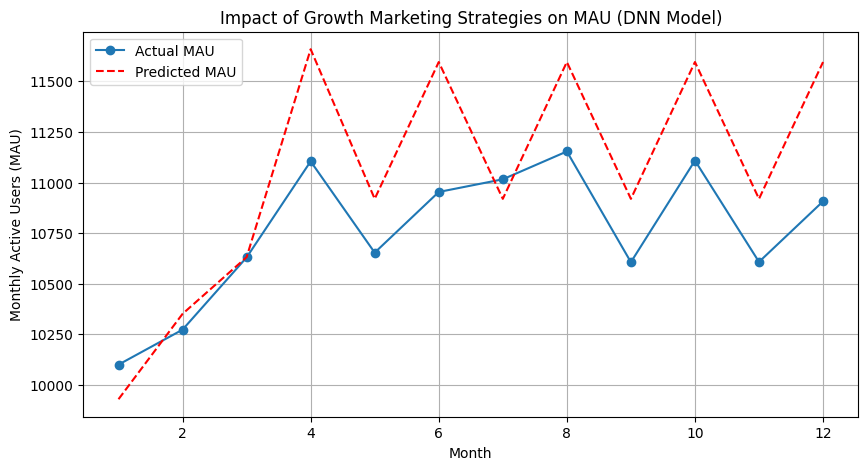

In [4]:
# 모델 학습
history = model.fit(X_scaled, y, epochs=10000, batch_size=4, validation_split=0.2, verbose=0)

# 예측 값 계산
y_pred = model.predict(X_scaled).flatten()

# 성능 평가
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(df["Month"], df["MAU"], label="Actual MAU", marker='o')
plt.plot(df["Month"], y_pred, label="Predicted MAU", linestyle="dashed", color="red")
plt.xlabel("Month")
plt.ylabel("Monthly Active Users (MAU)")
plt.title("Impact of Growth Marketing Strategies on MAU (DNN Model)")
plt.legend()
plt.grid()
plt.show()

### **시나리오: 계절성을 고려한 매출 예측 모델(DNN)**

한 회사는 3년간(2019~2021년)의 월별 매출 데이터를 분석하여 계절성을 반영한 매출 예측 모델을 개발하고자 한다.

특정 월의 매출 패턴은 다음과 같다.

- **여름(6~8월):** 매출 증가
- **겨울(12~2월):** 매출 감소
- **봄(3,5월) 및 가을(9,11월) :** 중간 수준

- DNN Learning

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# 데이터 생성 (3년간 월별 매출)
data = {
    'Year': [2019]*12 + [2020]*12 + [2021]*12,
    'Month': list(range(1, 13)) * 3,
    'Sales': [
        100, 120, 150, 200, 250, 300, 320, 310, 280, 230, 150, 110,
        105, 125, 160, 210, 260, 310, 330, 320, 290, 240, 160, 115,
        110, 130, 170, 220, 270, 320, 340, 330, 300, 250, 170, 120
    ]
}

df = pd.DataFrame(data)

# 계절 변수 추가 (Winter 포함)
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                             'Spring' if x in [3, 4, 5] else
                                             'Summer' if x in [6, 7, 8] else
                                             'Fall')

# 계절을 더미 변수로 변환 (Winter 포함, drop_first=False 유지)
df = pd.get_dummies(df, columns=['Season'], drop_first=False)

# 독립 변수(X)와 종속 변수(Y) 설정
X = df.drop(columns=['Sales', 'Year', 'Month'])
Y = df['Sales']

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할 (Train/Test)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# 모델 생성
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# 모델 컴파일 (손실 함수를 문자열 대신 객체로 지정)
model.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError(), metrics=['mae'])

# Early Stopping 설정 (과적합 방지)
early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=10, restore_best_weights=True
)

# 모델 학습
history = model.fit(X_train, Y_train, epochs=200, batch_size=4,
                    validation_data=(X_test, Y_test), callbacks=[early_stopping], verbose=0)

# 모델 평가
loss, mae = model.evaluate(X_test, Y_test)
print(f"Test Mean Absolute Error (MAE): {mae:.2f}")

# 모델 저장
model.save("sales_prediction_model.h5")
print("모델이 'sales_prediction_model.h5'로 저장되었습니다.")

# 정규화 객체 저장
joblib.dump(scaler, "scaler.pkl")
print("입력 데이터 정규화를 위한 scaler.pkl 파일이 저장되었습니다.")

# 저장된 feature 정보 저장 (나중에 같은 feature 순서를 유지하기 위해)
joblib.dump(X.columns.tolist(), "feature_names.pkl")
print("입력 데이터의 feature 정보가 feature_names.pkl 파일로 저장되었습니다.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 566.4406 - mae: 15.8789


Test Mean Absolute Error (MAE): 15.88
모델이 'sales_prediction_model.h5'로 저장되었습니다.
입력 데이터 정규화를 위한 scaler.pkl 파일이 저장되었습니다.
입력 데이터의 feature 정보가 feature_names.pkl 파일로 저장되었습니다.


- Model test

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

# 저장된 모델 로드
loaded_model = tf.keras.models.load_model("sales_prediction_model.h5")
loaded_model.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError(), metrics=['mae'])
print("저장된 모델이 로드되었습니다.")

# 저장된 정규화 객체 및 feature 정보 로드
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

# 새로운 입력값 생성 (훈련 데이터와 동일한 feature 순서 유지)
new_data = pd.DataFrame(columns=feature_names, data=[[0, 1, 0, 0]])  # 봄(Season_Spring=1)
print("새로운 입력값:")
print(new_data)

# 입력값 정규화
new_data_scaled = scaler.transform(new_data)

# 예측 수행
predicted_sales = loaded_model.predict(new_data_scaled).flatten()
print(f"예측된 매출: {predicted_sales[0]:.2f}")

저장된 모델이 로드되었습니다.
새로운 입력값:
   Season_Fall  Season_Spring  Season_Summer  Season_Winter
0            0              1              0              0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
예측된 매출: 223.69
